# TAME Training Dynamics & MoE Gating Analysis

In diesem Notebook werten wir die Trainings-Dynamiken aus dem HPC Skript (`scripts/tame_training_dynamics.py`) aus.
Die gespeicherten Artefakte aus `results/` werden geladen und geplottet:
1. **Train vs. Validation Loss** über die Epochen (Mean ± Std)
2. **MoE Gating Contributions** über die Epochen (Mean ± Std)
3. **Gate Distributions**: Wie verteilen sich die Gates für individuelle Moleküle?


In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Workspace Root hinzufügen
here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / "models").exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

In [2]:
# ====================================================================
# 1. Laden der HPC Artefakte
# ====================================================================

#results_dir = workspace_root / "benchmarking" / "results"
results_dir = Path("/home/robert/Downloads/tame_bace_hpo/d09")
with open(results_dir / "tame_dynamics_histories.json", "r") as f:
    all_histories = json.load(f)
    
gates_data = np.load(results_dir / "tame_dynamics_gates.npz")
graph_gates = gates_data["graph_gates"]
text_gates = gates_data["text_gates"]
desc_gates = gates_data["desc_gates"]

In [3]:
# ====================================================================
# 2. Hilfsfunktion fürs Plotten aggregierter Listen
# ====================================================================
def pad_histories(hist_list, key):
    """Padded ungleiche Epochenlängen mit NaN, damit wir mean/std berechnen können."""
    max_len = max(len(h[key]) for h in hist_list)
    padded = []
    for h in hist_list:
        arr = np.array(h[key], dtype=np.float32)
        pad_width = max_len - len(arr)
        padded.append(np.pad(arr, (0, pad_width), constant_values=np.nan))
    matrix = np.stack(padded)
    return np.nanmean(matrix, axis=0), np.nanstd(matrix, axis=0)

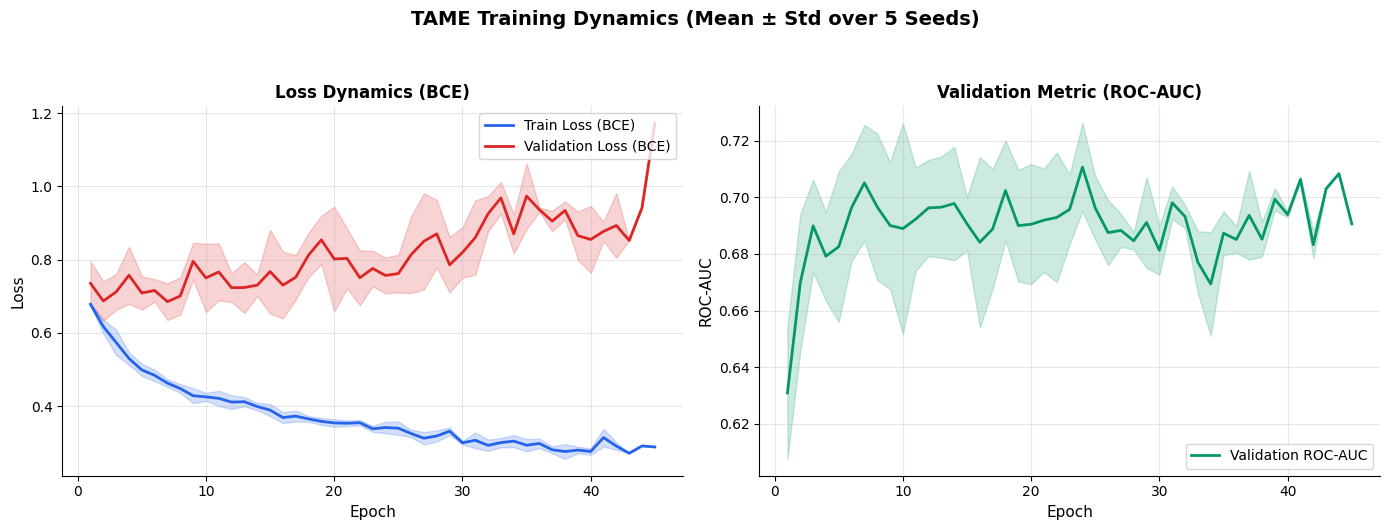

In [4]:
# ====================================================================
# 3. Plot: Loss Dynamics & ROC-AUC
# ====================================================================
plt.style.use("default")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

train_mean, train_std = pad_histories(all_histories, "train_loss")
val_mean, val_std = pad_histories(all_histories, "val_loss")
val_auc_mean, val_auc_std = pad_histories(all_histories, "val_auc")
epochs = np.arange(1, len(train_mean) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_mean, label="Train Loss (BCE)", color="#2563eb", linewidth=2)
axes[0].fill_between(epochs, train_mean - train_std, train_mean + train_std, color="#2563eb", alpha=0.2)

axes[0].plot(epochs, val_mean, label="Validation Loss (BCE)", color="#dc2626", linewidth=2)
axes[0].fill_between(epochs, val_mean - val_std, val_mean + val_std, color="#dc2626", alpha=0.2)

# Mark early stopping epoch for each seed (dotted grey lines)
for h in all_histories:
    es_ep = len(h["val_loss"])
    axes[0].axvline(es_ep, color="gray", linestyle=":", alpha=0.35, linewidth=1)
    axes[1].axvline(es_ep, color="gray", linestyle=":", alpha=0.35, linewidth=1)

axes[0].set_title("Loss Dynamics (BCE)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].legend(loc="upper right")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(epochs, val_auc_mean, label="Validation ROC-AUC", color="#059669", linewidth=2)
axes[1].fill_between(epochs, val_auc_mean - val_auc_std, val_auc_mean + val_auc_std, color="#059669", alpha=0.2)
axes[1].set_title("Validation Metric (ROC-AUC)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("ROC-AUC", fontsize=11)
axes[1].legend(loc="lower right")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("TAME Training Dynamics (Mean \u00b1 Std over 5 Seeds)", y=1.05, fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

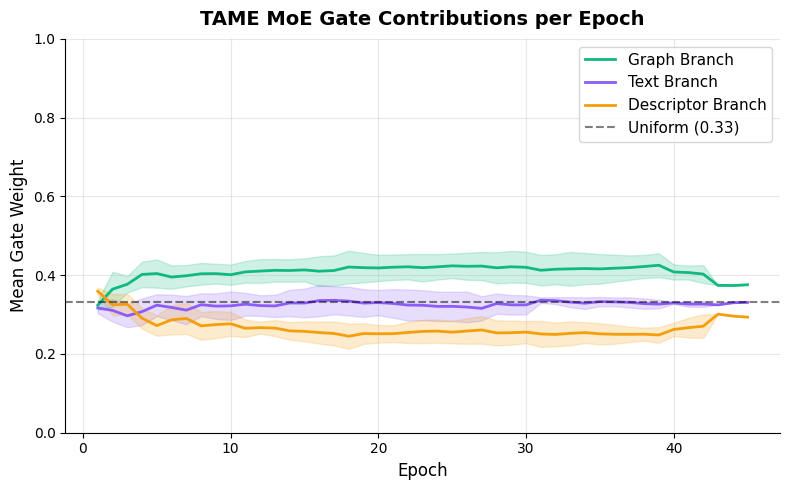

In [5]:
# ====================================================================
# 4. Plot: MoE Gate Contributions über die Epochen
# ====================================================================
g_mean, g_std = pad_histories(all_histories, "graph_gate")
t_mean, t_std = pad_histories(all_histories, "text_gate")
d_mean, d_std = pad_histories(all_histories, "desc_gate")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, g_mean, label="Graph Branch", color="#10b981", linewidth=2)
ax.fill_between(epochs, g_mean - g_std, g_mean + g_std, color="#10b981", alpha=0.2)

ax.plot(epochs, t_mean, label="Text Branch", color="#8b5cf6", linewidth=2)
ax.fill_between(epochs, t_mean - t_std, t_mean + t_std, color="#8b5cf6", alpha=0.2)

ax.plot(epochs, d_mean, label="Descriptor Branch", color="#f59e0b", linewidth=2)
ax.fill_between(epochs, d_mean - d_std, d_mean + d_std, color="#f59e0b", alpha=0.2)

ax.set_title("TAME MoE Gate Contributions per Epoch", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Mean Gate Weight", fontsize=12)
ax.set_ylim(0, 1.0)
ax.axhline(0.333, color="black", linestyle="--", alpha=0.5, label="Uniform (0.33)")
ax.legend(loc="upper right", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Insight: Distribution of Gates (MoE Collapse Check)
Zeigt, ob das Modell lernt, pro Molekül individuelle Gates zu vergeben, oder ob es in einen Modality Collapse fällt und jeden Branch hart mit 0.33 gewichtet.

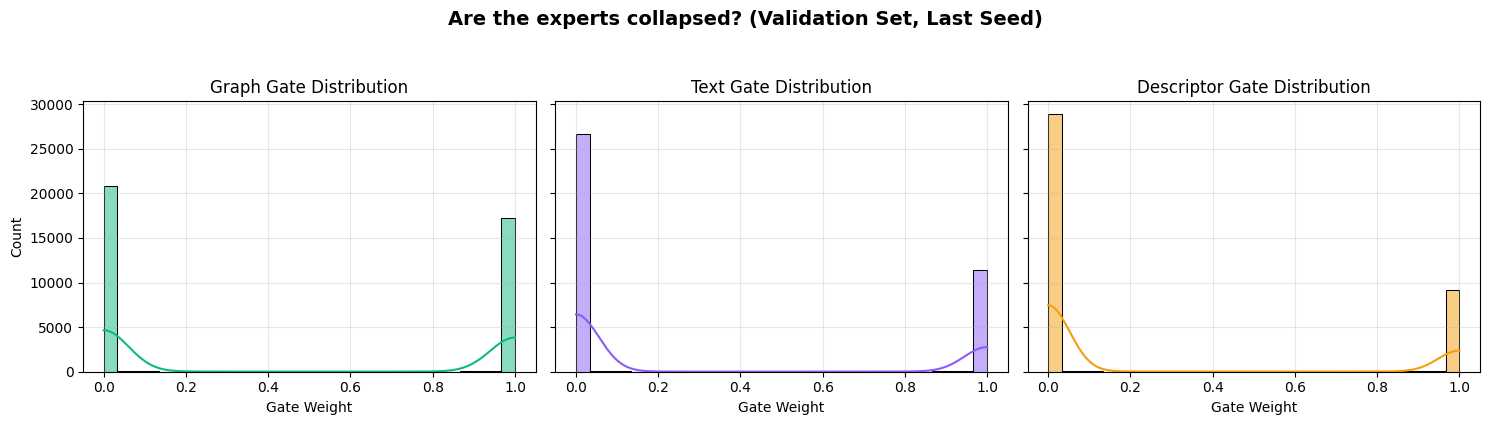

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# 1. Daten in flache 1D-Arrays umwandeln, um das Legenden/Performance-Problem zu lösen
g_gates_flat = np.array(graph_gates).flatten()
t_gates_flat = np.array(text_gates).flatten()
d_gates_flat = np.array(desc_gates).flatten()

# 2. legend=False hinzufügen
sns.histplot(g_gates_flat, bins=30, ax=axes[0], color="#10b981", kde=True, legend=False)
axes[0].set_title("Graph Gate Distribution")
axes[0].set_xlabel("Gate Weight")

sns.histplot(t_gates_flat, bins=30, ax=axes[1], color="#8b5cf6", kde=True, legend=False)
axes[1].set_title("Text Gate Distribution")
axes[1].set_xlabel("Gate Weight")

sns.histplot(d_gates_flat, bins=30, ax=axes[2], color="#f59e0b", kde=True, legend=False)
axes[2].set_title("Descriptor Gate Distribution")
axes[2].set_xlabel("Gate Weight")

plt.suptitle("Are the experts collapsed? (Validation Set, Last Seed)", y=1.05, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Gate Entropy Diagnostic

Per-position gate entropy: $H_i = -\sum_k g_{ik} \log g_{ik}$

- **Max entropy** (uniform, 3 experts): $\log(3) \approx 1.099$ — fully soft routing
- **Zero entropy** (hard): 0 — one expert takes all weight at that position

Hard routing with balanced means (~1/3 each) is **not modality collapse** — all branches
contribute, but at different hidden-dimension positions. However it impedes gradient flow
to the unused expert per position. Use `gate_entropy_weight > 0` to encourage softer routing.

In [ ]:
# ====================================================================
# 6. Gate entropy diagnostic
# ====================================================================
eps = 1e-8
g_g = np.array(graph_gates)  # (N_val, hidden_dim)
g_t = np.array(text_gates)
g_d = np.array(desc_gates)
ent = -(g_g * np.log(g_g + eps) + g_t * np.log(g_t + eps) + g_d * np.log(g_d + eps))  # (N_val, hidden_dim)

max_entropy = np.log(3)  # 3 experts

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(ent.flatten(), bins=60, kde=True, ax=ax, color="#6366f1", legend=False)
ax.axvline(max_entropy, color="#dc2626", linestyle="--", linewidth=1.5,
           label=f"Max entropy (log 3 \u2248 {max_entropy:.3f})")
ax.axvline(0.0, color="#f59e0b", linestyle="--", linewidth=1.5,
           label="Hard routing (entropy = 0)")
ax.set_xlabel("Per-position gate entropy", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Gate Entropy Distribution (Validation Set, Last Seed)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

mean_ent = ent.flatten().mean()
print(f"Mean gate entropy: {mean_ent:.4f}  (max = {max_entropy:.4f}, {100*mean_ent/max_entropy:.1f}% of max)")
plt.tight_layout()
plt.show()